In [1]:
# Kaggle setup and Imports
import os
import gc
import cv2
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from pathlib import Path
from tqdm.auto import tqdm
from sklearn.model_selection import train_test_split
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.preprocessing.image import ImageDataGenerator

gpus = tf.config.list_physical_devices('GPU')
if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
        print(f"✅ GPU configured: {len(gpus)} GPU(s) detected")
    except RuntimeError as e:
        print(f"⚠️ GPU config warning: {e}")
else:
    print("⚠️ No GPU found - will run on CPU")

KAGGLE_INPUT_ROOT = Path('/kaggle/input')
KAGGLE_WORKING_ROOT = Path('/kaggle/working')

# If running locally, you can change this path
# UFPR_AMR_ROOT = Path('xlg11E-UFPR-AMR/UFPR-AMR Dataset') 
UFPR_AMR_ROOT = KAGGLE_INPUT_ROOT / 'ufpr-amr-dataset' / 'UFPR-AMR Dataset'

2026-04-06 23:53:18.642945: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1775519598.868883      24 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1775519598.931488      24 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1775519599.425615      24 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1775519599.425660      24 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1775519599.425663      24 computation_placer.cc:177] computation placer alr

✅ GPU configured: 2 GPU(s) detected


In [2]:
# UFPR-AMR Dataset parsing
def load_ufpr_digits(dataset_root: Path):
    X, y = [], []
    
    # We parse training, validation, testing
    splits = ['training', 'validation', 'testing']
    
    for split in splits:
        split_dir = dataset_root / split
        if not split_dir.exists():
            continue
            
        txt_files = list(split_dir.rglob('*.txt'))
        print(f"Parsing {len(txt_files)} annotations from {split}...")
        
        for txt_path in tqdm(txt_files, desc=split):
            if 'README' in txt_path.name:
                continue
                
            with open(txt_path, 'r', encoding='utf-8') as f:
                lines = f.read().splitlines()
                
            reading = ""
            digits_boxes = []
            
            for line in lines:
                line = line.strip().lower()
                if line.startswith("reading:"):
                    reading = line.replace("reading:", "").strip()
                elif line.startswith("digit"):
                    # Example: `digit 1: 1015 1982 58 96`
                    parts = line.split(":")
                    if len(parts) == 2:
                        try:
                            x_val, y_val, w_val, h_val = map(int, parts[1].strip().split()[:4])
                            digits_boxes.append((x_val, y_val, w_val, h_val))
                        except ValueError:
                            pass
            
            # Ensure number of digits matches the reading length
            if len(reading) > 0 and len(reading) == len(digits_boxes):
                img_path = None
                for ext in ['.jpg', '.JPG', '.png', '.jpeg']:
                    cand = txt_path.with_suffix(ext)
                    if cand.exists():
                        img_path = cand
                        break
                        
                if img_path is None:
                    continue
                    
                img = cv2.imread(str(img_path))
                if img is None:
                    continue
                    
                img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
                
                for idx, (dx, dy, dw, dh) in enumerate(digits_boxes):
                    # Crop digit
                    crop = img[dy:dy+dh, dx:dx+dw]
                    if crop.size == 0:
                        continue
                        
                    # Resize to (width=20, height=32)
                    crop_resized = cv2.resize(crop, (20, 32))
                    X.append(crop_resized)
                    
                    char = reading[idx]
                    # Encode label: 'N' translates to 10
                    label = 10 if char.upper() == 'N' else int(char)
                    y.append(label)

    return np.array(X, dtype=np.float32), np.array(y, dtype=np.int32)

# Adjust this path if testing locally
if not UFPR_AMR_ROOT.exists():
    # local fallback
    UFPR_AMR_ROOT = Path("/kaggle/input/datasets/anassouzaouit/dataset-ratt/UFPR-AMR Dataset")
    if not UFPR_AMR_ROOT.exists():
        print("⚠️ UFPR dataset path not found. Please mount UFPR-AMR dataset into Kaggle at /kaggle/input")
else:
    print(f"✅ Found UFPR-AMR dataset at: {UFPR_AMR_ROOT}")

# Load the data
print("Extracting cropped digits...")
X_all, y_all = load_ufpr_digits(UFPR_AMR_ROOT)

print(f"Total digits extracted: {X_all.shape}")
print(f"Total labels extracted: {y_all.shape}")

Extracting cropped digits...
Parsing 800 annotations from training...


training:   0%|          | 0/800 [00:00<?, ?it/s]

Parsing 400 annotations from validation...


validation:   0%|          | 0/400 [00:00<?, ?it/s]

Parsing 800 annotations from testing...


testing:   0%|          | 0/800 [00:00<?, ?it/s]

Total digits extracted: (9960, 32, 20, 3)
Total labels extracted: (9960,)


In [3]:
# Prepare dataset properties
from sklearn.utils import shuffle

# One-hot encode the target labels (11 classes)
y_all_encoded = to_categorical(y_all, num_classes=11)

# Perform shuffle for randomization
X_data, y_data = shuffle(X_all, y_all_encoded, random_state=42)

# Train-test split (80% training, 20% validation/test)
X_train, X_test, y_train, y_test = train_test_split(X_data, y_data, test_size=0.20, random_state=42)

print("Training Data: X_shape =", X_train.shape, "| y_shape =", y_train.shape)
print("Testing Data:  X_shape =", X_test.shape, "| y_shape =", y_test.shape)

# Important rule: Keep raw pixels! No division by 255.0
print("Sample min-max pixel values (Should be 0-255 range strictly):", X_train[0].min(), "-", X_train[0].max())


Training Data: X_shape = (7968, 32, 20, 3) | y_shape = (7968, 11)
Testing Data:  X_shape = (1992, 32, 20, 3) | y_shape = (1992, 11)
Sample min-max pixel values (Should be 0-255 range strictly): 50.0 - 200.0


In [4]:
# CNN Architecture definition (matches upgraded-finaltest.ipynb setup without 1/255 normalization)
input_layer = tf.keras.Input(shape=(32, 20, 3))
x = tf.keras.layers.BatchNormalization()(input_layer)

# First conv block
x = tf.keras.layers.Conv2D(64, 3, padding='same', activation='relu')(x)
x = tf.keras.layers.BatchNormalization()(x)
x = tf.keras.layers.Conv2D(64, 3, padding='same', activation='relu')(x)
x = tf.keras.layers.MaxPool2D(2)(x)
x = tf.keras.layers.Dropout(0.25)(x)

# Second conv block
x = tf.keras.layers.Conv2D(128, 3, padding='same', activation='relu')(x)
x = tf.keras.layers.BatchNormalization()(x)
x = tf.keras.layers.Conv2D(128, 3, padding='same', activation='relu')(x)
x = tf.keras.layers.MaxPool2D(2)(x)
x = tf.keras.layers.Dropout(0.25)(x)

# Third conv block
x = tf.keras.layers.Conv2D(256, 3, padding='same', activation='relu')(x)
x = tf.keras.layers.BatchNormalization()(x)
x = tf.keras.layers.MaxPool2D(2)(x)
x = tf.keras.layers.Dropout(0.25)(x)

# Dense layers
x = tf.keras.layers.Flatten()(x)
x = tf.keras.layers.Dense(512, activation='relu')(x)
x = tf.keras.layers.BatchNormalization()(x)
x = tf.keras.layers.Dropout(0.5)(x)
x = tf.keras.layers.Dense(256, activation='relu')(x)
x = tf.keras.layers.Dropout(0.5)(x)

# Output classification for 11 categories (digits 0-9 + class 10='NaN')
output = tf.keras.layers.Dense(11, activation='softmax')(x)

model = tf.keras.Model(inputs=input_layer, outputs=output)

# 4. Compilation
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print("CNN architecture summary:")
model.summary()

I0000 00:00:1775519872.184081      24 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1775519872.190192      24 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


CNN architecture summary:


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 32, 20, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 32, 20, 3)      │            12 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 32, 20, 64)     │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 32, 20, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 32, 20, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 10, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 16, 10, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 16, 10, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 16, 10, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 16, 10, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 5, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 8, 5, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 8, 5, 256)      │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 8, 5, 256)      │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 4, 2, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 4, 2, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │     1,049,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 1,742,423 (6.65 MB)

 Trainable params: 1,740,497 (6.64 MB)

 Non-trainable params: 1,926 (7.52 KB)

Beginning Training for up to 150 epochs...
Epoch 1/150


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()
I0000 00:00:1775519877.356824      76 service.cc:152] XLA service 0x7f8870002320 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1775519877.356895      76 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1775519877.356902      76 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1775519878.181006      76 cuda_dnn.cc:529] Loaded cuDNN version 91002


  5/125 ━━━━━━━━━━━━━━━━━━━━ 4s 38ms/step - accuracy: 0.1068 - loss: 4.2280

I0000 00:00:1775519885.887873      76 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 98ms/step - accuracy: 0.1478 - loss: 3.3842
Epoch 1: val_accuracy improved from -inf to 0.22440, saving model to cnn_model.keras
125/125 ━━━━━━━━━━━━━━━━━━━━ 28s 130ms/step - accuracy: 0.1482 - loss: 3.3805 - val_accuracy: 0.2244 - val_loss: 2.1771 - learning_rate: 0.0010
Epoch 2/150
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - accuracy: 0.4420 - loss: 1.7902
Epoch 2: val_accuracy improved from 0.22440 to 0.58283, saving model to cnn_model.keras
125/125 ━━━━━━━━━━━━━━━━━━━━ 7s 54ms/step - accuracy: 0.4427 - loss: 1.7877 - val_accuracy: 0.5828 - val_loss: 1.3116 - learning_rate: 0.0010
Epoch 3/150
124/125 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - accuracy: 0.7380 - loss: 0.8309
Epoch 3: val_accuracy improved from 0.58283 to 0.78966, saving model to cnn_model.keras
125/125 ━━━━━━━━━━━━━━━━━━━━ 7s 54ms/step - accuracy: 0.7384 - loss: 0.8296 - val_accuracy: 0.7897 - val_loss: 0.6828 - learning_rate: 0.0010
Epoch 4/150
124/125 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - acc

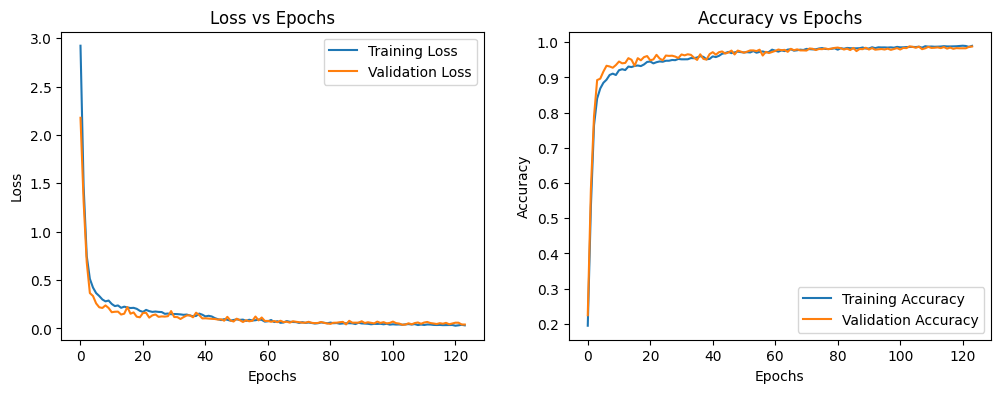

In [5]:
# Compile Strategy & Callbacks Setup
batch_size = 64
epochs = 150

# Augmentation strategy: Add rotations, zooming to account for meter misalignments.
datagen = ImageDataGenerator(
    width_shift_range=0.15,
    height_shift_range=0.15,
    brightness_range=[0.7, 1.3],
    zoom_range=0.2,
    rotation_range=10,
    shear_range=0.15,
    fill_mode='nearest'
)

callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor='val_loss',
        patience=20,
        restore_best_weights=True,
        verbose=1
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=10,
        min_lr=1e-7,
        verbose=1
    ),
    tf.keras.callbacks.ModelCheckpoint(
        'cnn_model.keras',
        monitor='val_accuracy', # Checkpoint best validation accuracy model
        save_best_only=True,
        verbose=1
    )
]

train_generator = datagen.flow(X_train, y_train, batch_size=batch_size)
val_generator = datagen.flow(X_test, y_test, batch_size=batch_size, shuffle=False)

print(f"Beginning Training for up to {epochs} epochs...")

# Training execution
history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=epochs,
    callbacks=callbacks,
    verbose=1
)

# Render loss & accuracy plots
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.title('Loss vs Epochs')

plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.title('Accuracy vs Epochs')

plt.show()

Evaluating final model on hold-out validation/test set...
Final Model accuracy: 99.00%

Classification Report:

              precision    recall  f1-score   support

           0       0.99      1.00      0.99       340
           1       0.98      0.99      0.99       282
           2       1.00      0.99      0.99       207
           3       0.99      0.99      0.99       181
           4       1.00      0.99      1.00       181
           5       1.00      0.99      0.99       171
           6       0.97      0.99      0.98       144
           7       0.99      0.99      0.99       163
           8       0.98      0.99      0.98       164
           9       0.99      0.98      0.99       159

    accuracy                           0.99      1992
   macro avg       0.99      0.99      0.99      1992
weighted avg       0.99      0.99      0.99      1992



AttributeError: QuadMesh.set() got an unexpected keyword argument 'ftfmt'

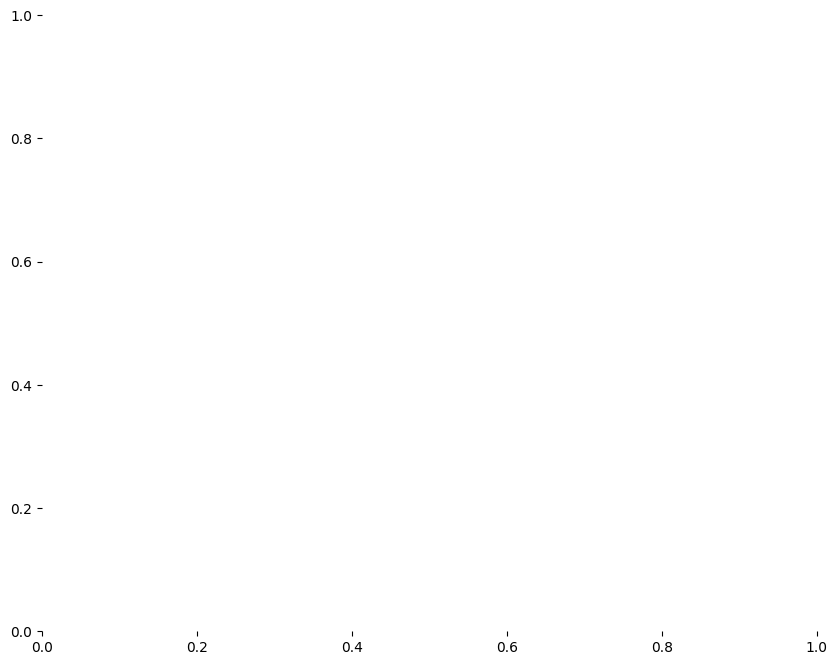

In [6]:
# Load & Evaluate the best model 
model_loaded = tf.keras.models.load_model('cnn_model.keras')

print("Evaluating final model on hold-out validation/test set...")
loss, accuracy = model_loaded.evaluate(X_test, y_test, verbose=0)
print(f"Final Model accuracy: {accuracy*100:.2f}%")

# Generate Classification Matrix and Detailed Report
predictions = model_loaded.predict(X_test, verbose=0)
y_pred_classes = np.argmax(predictions, axis=1)
y_true_classes = np.argmax(y_test, axis=1)

from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

print("\nClassification Report:\n")
print(classification_report(y_true_classes, y_pred_classes))

cm = confusion_matrix(y_true_classes, y_pred_classes)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, ftfmt='d', cmap='Blues',
            xticklabels=[str(i) for i in range(10)] + ['N'],
            yticklabels=[str(i) for i in range(10)] + ['N'])
plt.title('Confusion Matrix - CNN Predictions (UFPR-AMR raw digits)')
plt.xlabel('Predicted')
plt.ylabel('True Label')
plt.show()

# If running strictly on Kaggle notebook, we ensure output is in Working Dir
import shutil
if Path('cnn_model.keras').exists():
    export_path = KAGGLE_WORKING_ROOT / 'cnn_model.keras'
    shutil.copy("cnn_model.keras", export_path)
    print(f"✅ Successfully exported 'cnn_model.keras' to {export_path}")